# Gurgaon Real-Estate Data Pipeline
### Cleaning → Feature Engineering → EDA → Missing Value Imputation → Outlier Removal

**Source:** raw 99acres scrape, `gurgaon_10k.csv` (10,704 listings, 67 raw columns)

This notebook takes the raw scraped export and turns it into a modeling-ready dataset.
It is organised as a linear pipeline — run top to bottom. Each stage saves an intermediate
checkpoint CSV so you can jump in at any stage later.

**Pipeline stages**
1. Load & first look
2. Column audit (what to keep / drop, and why)
3. Parsing nested JSON-ish columns
4. Core cleaning (dtypes, renaming, dedup)
5. Feature engineering
6. Exploratory Data Analysis
7. Missing value imputation
8. Outlier detection & removal
9. Export final dataset


In [1]:
import pandas as pd
import numpy as np
import ast
import re
import json
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import IsolationForest

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

RAW_PATH = '../../data/raw/gurgoan/flats/flats_gurgoan.csv'
OUT_DIR = '../../data/processed/gurgaon'
import os
os.makedirs(OUT_DIR, exist_ok=True)


## 1. Load & First Look

In [2]:
df = pd.read_csv(RAW_PATH, low_memory=False)
print('Shape:', df.shape)
df.head(3)


Shape: (10704, 67)


,PROP_ID,PHOTO_URL,MEDIUM_PHOTO_URL,PREFERENCE,DESCRIPTION,PROPERTY_TYPE,CITY,LOCALITY,TRANSACT_TYPE,OWNTYPE,BEDROOM_NUM,BATHROOM_NUM,BALCONY_NUM,PRICE_PER_UNIT_AREA,FURNISH,FACING,AGE,FLOOR_NUM,TOTAL_FLOOR,FEATURES,REGISTER_DATE,PROP_NAME,MIN_PRICE,MAX_PRICE,PRICE_SQFT,LISTING,BUILDING_ID,CARPET_SQFT,SUPERBUILTUP_SQFT,BROKERAGE,MAP_DETAILS,FSL_Data,MIN_AREA_SQFT,MAX_AREA_SQFT,FORMATTED,AMENITIES,TOP_USPS,PD_URL,EXPIRY_DATE,GROUP_NAME,AREA,PRICE,PROP_HEADING,PROP_DETAILS_URL,CLASS_HEADING,CLASS_LABEL,SECONDARY_TAGS,PROPERTY_IMAGES,THUMBNAIL_IMAGES,TOTAL_LANDMARK_COUNT,FORMATTED_LANDMARK_DETAILS,CONTACT_NAME,CONTACT_COMPANY_NAME,DEALER_PHOTO_URL,SOCIETY_NAME,BUILDING_NAME,CITY_ID,LOCALITY_WO_CITY,profile,xid,metadata,location,BUILTUP_SQFT,SUPER_SQFT,COMMON_FURNISHING_ATTRIBUTES,QUALITY_SCORE,FURNISHING_ATTRIBUTES
0,O71585872,https://mediacdn.99acres.com/media1/22409/13/4...,https://mediacdn.99acres.com/media1/22409/13/4...,S,4 bhk flat for resale in alpha corp gurgaon one,Residential Apartment,Gurgaon,Sector 84 Gurgaon,1.0,1,4.0,4,4.0,8766.0,4,1,2,14,26.0,"33,23,12,46,25,47,39,1,3,6,9,40,41,30,20,42,21,32","29th Sep, 2023",Alpha Corp GurgaonOne 84,26300000,26300000,8766.0,R,10532,3000.0,3434.0,263000.0,"{'LATITUDE': '28.4065341', 'LONGITUDE': '76.96...",{'LOCALITY_ID': 0},319.028902,319.028902,"{'AVAIL': {'AVAILABILITY': 2, 'SUB_AVAILABILIT...","20,21,32,23,46,47,39,1,6,9,40,41,30,42,33,12,2...","['North Facing', 'Recently Renovated', 'Gated ...",/4-bhk-bedroom-apartment-flat-for-sale-in-alph...,2023-11-28 00:00:00,SPID_GROUP_SEARCH_NORMAL,3434 sq.ft.,2.63 Cr,4 BHK Flat in Sector 84 Gurgaon,4-bhk-bedroom-apartment-flat-for-sale-in-alpha...,Dealer: propertyline,Dealer,"['READY TO MOVE', 'RESALE']",['https://mediacdn.99acres.com/media1/22409/13...,['https://mediacdn.99acres.com/media1/22409/13...,10.0,"[{'category': 'Shopping', 'text': '4 Shoppings...",gaurav khosla,propertyline,https://static.99acres.com/images/dealer_pnava...,Alpha Corp GurgaonOne 84,Alpha Corp GurgaonOne 84,8,Sector 84,"{'CONTACT_NAME': 'gaurav khosla', 'CONTACT_COM...","{'PROJECTID': 5096, 'PROJ_NAME': 'Alpha Corp G...","{'PROP_PHOTO_COUNT': '4', 'PROP_VIDEO_COUNT': ...","{'CITY': '8', 'CITY_NAME': 'Gurgaon', 'BUILDIN...",NaN,NaN,NaN,NaN,NaN
1,T71585466,https://mediacdn.99acres.com/media1/22425/6/44...,https://mediacdn.99acres.com/media1/22425/6/44...,S,"Explore dlf ultima, an upscale ready-To-Move h...",Residential Apartment,Gurgaon,Sector 81 Gurgaon,1.0,1,4.0,4,3.0,21176.0,4,1,1,7,29.0,"44,33,23,12,46,25,47,26,17,29,19,1,3,5,6,9,30,...","29th Sep, 2023",DLF The Ultima,36000000,36000000,21176.0,R,12704,1700.0,2870.0,1.0,"{'LATITUDE': '28.3889069', 'LONGITUDE': '76.95...",{'LOCALITY_ID': 0},266.631610,266.631610,"{'AVAIL': {'AVAILABILITY': 2, 'SUB_AVAILABILIT...","17,5,20,21,10,44,23,46,47,29,19,1,6,9,30,41,43...","['North Facing', ""st. xavier's within 500m"", '...",/4-bhk-bedroom-apartment-flat-for-sale-in-dlf-...,2023-11-28 00:00:00,SPID_GROUP_SEARCH_NORMAL,2870 sq.ft.,3.6 Cr,4 BHK Flat in Sector 81 Gurgaon,4-bhk-bedroom-apartment-flat-for-sale-in-dlf-t...,Dealer: MVD AND ASSOCIATES,Dealer,"['READY TO MOVE', 'RESALE', 'RERA']",['https://mediacdn.99acres.com/media1/22425/6/...,['https://mediacdn.99acres.com/media1/22425/6/...,9.0,"[{'category': 'MetroStation', 'text': '1 Metro...",Kamal,MVD AND ASSOCIATES,https://static.99acres.com/images/dealer_pnava...,DLF The Ultima,DLF The Ultima,8,Sector 81,"{'CONTACT_NAME': 'Kamal', 'CONTACT_COMPANY_NAM...","{'PROJECTID': 7182, 'PROJ_NAME': 'DLF The Ulti...","{'PROP_PHOTO_COUNT': '4', 'PROP_VIDEO_COUNT': ...","{'CITY': '8', 'CITY_NAME': 'Gurgaon', 'BUILDIN...",NaN,NaN,NaN,NaN,NaN
2,D71549524,https://mediacdn.99acres.com/media1/22386/13/4...,https://mediacdn.99acres.com/media1/22386/13/4...,R,A 3 bhk flat for rent in sector 66 gurgaon clo...,Residential Apartment,Gurgaon,Sector 66 Gurgaon,NaN,0,3.0,3,2.0,43.0,1,4,1,7,17.0,"44,23,45,24,46,25,47,28,29,30,31,32,33,12,17,3...","27th Sep, 2023",Emaar MGF The Palm Drive,8500

In [3]:
df.info(max_cols=100, show_counts=True)


<class 'pandas.DataFrame'>
RangeIndex: 10704 entries, 0 to 10703
Data columns (total 67 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROP_ID                       10704 non-null  str    
 1   PHOTO_URL                     8864 non-null   str    
 2   MEDIUM_PHOTO_URL              8864 non-null   str    
 3   PREFERENCE                    10704 non-null  str    
 4   DESCRIPTION                   10704 non-null  str    
 5   PROPERTY_TYPE                 10704 non-null  str    
 6   CITY                          10704 non-null  str    
 7   LOCALITY                      10704 non-null  str    
 8   TRANSACT_TYPE                 10152 non-null  float64
 9   OWNTYPE                       10704 non-null  int64  
 10  BEDROOM_NUM                   10511 non-null  float64
 11  BATHROOM_NUM                  10704 non-null  int64  
 12  BALCONY_NUM                   10501 non-null  float64
 13  PRICE_PER_UN

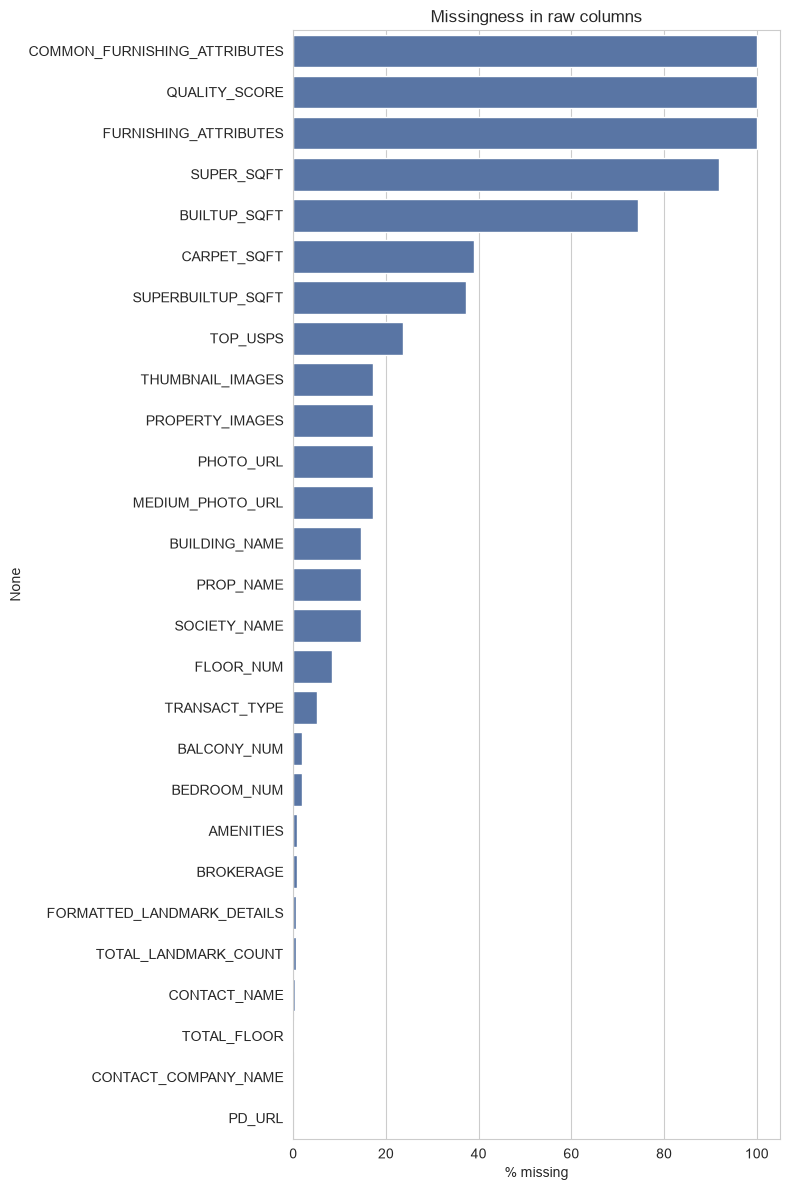

In [4]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
plt.figure(figsize=(8, 12))
sns.barplot(x=missing.values, y=missing.index, color='#4C72B0')
plt.xlabel('% missing')
plt.title('Missingness in raw columns')
plt.tight_layout()
plt.show()


## 2. Column Audit

The raw export mixes genuinely useful listing attributes with scraping artifacts
(image URLs, dealer photos, page URLs) and duplicated/near-duplicated fields
(e.g. `MIN_PRICE`/`MAX_PRICE`/`PRICE` all encode the same price in different forms).

**Decisions:**
- Drop pure scraping artifacts: photo/thumbnail/image URLs, dealer photo, page URLs, `xid`, `profile`.
- Drop columns that are almost entirely empty and have a reliable substitute:
  `BUILTUP_SQFT` (74% missing), `SUPER_SQFT` (92% missing), `QUALITY_SCORE` (99.98%),
  `COMMON_FURNISHING_ATTRIBUTES` (100%), `FURNISHING_ATTRIBUTES` (99.98%, superseded by the
  `FURNISH_LABEL` we extract from `FORMATTED`).
- Keep `MIN_PRICE`/`MIN_AREA_SQFT` as the canonical price/area (verified `MIN==MAX` for
  99.95% of rows — the rare mismatches are kept, we just use `MIN_*` consistently).
- Keep JSON-ish columns (`MAP_DETAILS`, `FORMATTED`, `SECONDARY_TAGS`, `TOP_USPS`,
  `FORMATTED_LANDMARK_DETAILS`, `AMENITIES`, `FEATURES`) — these are parsed into real
  features in section 3, not dropped outright.
- Raw categorical *codes* `FACING`, `AGE`, `OWNTYPE`, `TRANSACT_TYPE` come from 99acres'
  internal enumeration and aren't documented publicly. We keep them as **nominal**
  categorical features (not ordinal/labelled) rather than invent label names we can't verify.


In [5]:
DROP_COLS = [
    # scraping artifacts / not predictive
    'PHOTO_URL', 'MEDIUM_PHOTO_URL', 'PROPERTY_IMAGES', 'THUMBNAIL_IMAGES',
    'DEALER_PHOTO_URL', 'PD_URL', 'PROP_DETAILS_URL', 'xid', 'profile', 'location',
    'CLASS_HEADING', 'GROUP_NAME', 'LISTING', 'PROP_HEADING', 'CONTACT_NAME',
    'CONTACT_COMPANY_NAME', 'FSL_Data', 'BUILDING_ID', 'CITY_ID',
    # near-empty, unreliable, superseded
    'BUILTUP_SQFT', 'SUPER_SQFT', 'QUALITY_SCORE',
    'COMMON_FURNISHING_ATTRIBUTES', 'FURNISHING_ATTRIBUTES',
    # redundant with MIN_PRICE / MIN_AREA_SQFT / PRICE_SQFT
    'MAX_PRICE', 'MAX_AREA_SQFT', 'AREA', 'PRICE',
]

# Before dropping the image/URL columns above, save them separately keyed by PROP_ID.
# These are useless as *model features* (a photo URL doesn't predict price) but essential
# for *displaying* a listing in the frontend -- so they get their own file instead of
# being discarded outright.
def safe_eval_early(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return None

DISPLAY_COLS = ['PROP_ID', 'PHOTO_URL', 'MEDIUM_PHOTO_URL', 'PROPERTY_IMAGES',
                 'THUMBNAIL_IMAGES', 'DESCRIPTION', 'PROP_HEADING']
display_df = df[[c for c in DISPLAY_COLS if c in df.columns]].copy()

# PROPERTY_IMAGES / THUMBNAIL_IMAGES are Python list literals (multiple photos per
# listing) stored as strings -- parse and re-serialize as clean JSON arrays so the
# frontend/FastAPI layer can just json.loads() them directly, no ast.literal_eval needed.
import json as _json
for col in ['PROPERTY_IMAGES', 'THUMBNAIL_IMAGES']:
    parsed = display_df[col].apply(safe_eval_early)
    display_df[col] = parsed.apply(lambda x: _json.dumps(x) if x else '[]')

display_df.to_csv(f'{OUT_DIR}/listing_display.csv', index=False)
print('Saved listing_display.csv:', display_df.shape)

df1 = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()
print('Remaining columns:', df1.shape[1])


Saved listing_display.csv: (10704, 7)
Remaining columns: 39


In [38]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10704 entries, 0 to 10703
Data columns (total 61 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PROP_ID                     10704 non-null  str    
 1   PREFERENCE                  10704 non-null  str    
 2   DESCRIPTION                 10704 non-null  str    
 3   PROPERTY_TYPE               10704 non-null  str    
 4   CITY                        10704 non-null  str    
 5   LOCALITY                    10704 non-null  str    
 6   TRANSACT_TYPE               10152 non-null  float64
 7   OWNTYPE                     10704 non-null  int64  
 8   BEDROOM_NUM                 10511 non-null  float64
 9   BATHROOM_NUM                10704 non-null  int64  
 10  BALCONY_NUM                 10501 non-null  float64
 11  PRICE_PER_UNIT_AREA         10704 non-null  float64
 12  FURNISH                     10704 non-null  int64  
 13  FACING                      10704 non-null

## 3. Parsing Nested / JSON-ish Columns

Several columns are Python-dict / list literals stored as strings (an artifact of how
they were scraped). We parse each with `ast.literal_eval` (safe — no `eval`) and pull out
the fields that matter.


In [6]:
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return None

# --- MAP_DETAILS -> latitude / longitude
map_parsed = df1['MAP_DETAILS'].apply(safe_eval)
df1['LATITUDE'] = map_parsed.apply(lambda d: float(d['LATITUDE']) if d and d.get('LATITUDE') else np.nan)
df1['LONGITUDE'] = map_parsed.apply(lambda d: float(d['LONGITUDE']) if d and d.get('LONGITUDE') else np.nan)

# --- FORMATTED -> furnish label, RERA status
fmt_parsed = df1['FORMATTED'].apply(safe_eval)
df1['FURNISH_LABEL'] = fmt_parsed.apply(lambda d: d.get('FURNISH_LABEL') if d else None)
df1['RERA_STATUS'] = fmt_parsed.apply(lambda d: d.get('RERA_TYPE') if d else None)

print(df1[['LATITUDE', 'LONGITUDE', 'FURNISH_LABEL', 'RERA_STATUS']].head())


    LATITUDE  LONGITUDE  FURNISH_LABEL RERA_STATUS
0  28.406534  76.962792  Semifurnished        RERA
1  28.388907  76.951328  Semifurnished        RERA
2  28.401406  77.050549      Furnished        RERA
3  28.518677  77.015115  Semifurnished        RERA
4  28.478440  76.986110  Semifurnished        RERA


In [7]:
# --- SECONDARY_TAGS -> boolean flags
tags_parsed = df1['SECONDARY_TAGS'].apply(safe_eval)

def has_tag(tags, keyword):
    if not tags:
        return False
    return any(keyword.lower() in str(t).lower() for t in tags)

for flag, kw in [
    ('IS_READY_TO_MOVE', 'ready to move'),
    ('IS_RESALE', 'resale'),
    ('IS_RERA', 'rera'),
    ('IS_GATED_COMMUNITY', 'gated'),
    ('IS_HUDA_APPROVED', 'huda'),
]:
    df1[flag] = tags_parsed.apply(lambda t, kw=kw: has_tag(t, kw))

print(df1[['IS_READY_TO_MOVE', 'IS_RESALE', 'IS_RERA', 'IS_GATED_COMMUNITY', 'IS_HUDA_APPROVED']].mean())


IS_READY_TO_MOVE      0.779895
IS_RESALE             0.947309
IS_RERA               0.392937
IS_GATED_COMMUNITY    0.013546
IS_HUDA_APPROVED      0.007287
dtype: float64


In [8]:
# --- TOP_USPS -> facing direction (text-based, supplementary to FACING code) + usp count
usps_parsed = df1['TOP_USPS'].apply(safe_eval)

FACING_RE = re.compile(r'(North East|North West|South East|South West|North|South|East|West)[- ]Facing', re.I)

def extract_facing(usps):
    if not usps:
        return None
    for u in usps:
        m = FACING_RE.search(str(u))
        if m:
            return m.group(1).title()
    return None

df1['FACING_TEXT'] = usps_parsed.apply(extract_facing)
df1['USP_COUNT'] = usps_parsed.apply(lambda u: len(u) if u else 0)


In [9]:
# --- FORMATTED_LANDMARK_DETAILS -> per-category landmark counts
landmarks_parsed = df1['FORMATTED_LANDMARK_DETAILS'].apply(safe_eval)

def get_landmark_count(landmarks, category):
    if not landmarks:
        return 0
    for l in landmarks:
        if l.get('category') == category:
            m = re.search(r'\d+', l.get('text', ''))
            return int(m.group()) if m else 1
    return 0

for cat in ['Shopping', 'Education', 'Hospital', 'MetroStation', 'RailwayStation', 'Connectivity', 'Bank', 'Park']:
    df1[f'NEARBY_{cat.upper()}'] = landmarks_parsed.apply(lambda l, cat=cat: get_landmark_count(l, cat))

df1['TOTAL_NEARBY_LANDMARKS'] = df1['TOTAL_LANDMARK_COUNT'].fillna(0)


In [10]:
# --- AMENITIES / FEATURES -> counts (both are comma-separated numeric codes)
def count_csv_codes(s):
    if pd.isna(s) or str(s).strip() == '':
        return 0
    return len(str(s).split(','))

df1['AMENITIES_COUNT'] = df1['AMENITIES'].apply(count_csv_codes)
df1['FEATURES_COUNT'] = df1['FEATURES'].apply(count_csv_codes)


In [11]:
# Drop the now-parsed raw JSON/text columns
PARSED_RAW_COLS = ['MAP_DETAILS', 'FORMATTED', 'SECONDARY_TAGS', 'TOP_USPS',
                    'FORMATTED_LANDMARK_DETAILS', 'AMENITIES', 'FEATURES',
                    'TOTAL_LANDMARK_COUNT', 'metadata']
df2 = df1.drop(columns=[c for c in PARSED_RAW_COLS if c in df1.columns]).copy()
print('Shape after parsing stage:', df2.shape)


Shape after parsing stage: (10704, 52)


## 4. Core Data Cleaning

Now that the nested columns are parsed, we clean up dtypes, decode the one code column
we *can* confidently decode (`FURNISH`), parse dates, and check for duplicate listings.


In [12]:
df3 = df2.copy()

# CITY is constant ('Gurgaon' for every row) -> drop. LOCALITY and LOCALITY_WO_CITY carry
# the same information (231 unique values each) -> keep the cleaner LOCALITY_WO_CITY only.
df3 = df3.drop(columns=['CITY', 'LOCALITY', 'PRICE_PER_UNIT_AREA'])  # PRICE_PER_UNIT_AREA == PRICE_SQFT always

# FLOOR_NUM: 'G' (ground) -> 0, everything else to numeric
def parse_floor(v):
    if pd.isna(v):
        return np.nan
    v = str(v).strip()
    if v.upper() == 'G':
        return 0.0
    try:
        return float(v)
    except ValueError:
        return np.nan

df3['FLOOR_NUM'] = df3['FLOOR_NUM'].apply(parse_floor)

# FURNISH: confidently decoded by cross-checking against FURNISH_LABEL extracted in section 3
FURNISH_MAP = {0: 'Unknown', 1: 'Furnished', 2: 'Unfurnished', 4: 'Semifurnished'}
df3['FURNISH'] = df3['FURNISH'].map(FURNISH_MAP)

# Dates: '29th Sep, 2023' -> strip ordinal suffix, then parse
def clean_ordinal_date(s):
    if pd.isna(s):
        return np.nan
    return re.sub(r'(\d+)(st|nd|rd|th)', r'\1', str(s))

df3['REGISTER_DATE'] = pd.to_datetime(df3['REGISTER_DATE'].apply(clean_ordinal_date), format='%d %b, %Y', errors='coerce')
df3['EXPIRY_DATE'] = pd.to_datetime(df3['EXPIRY_DATE'], errors='coerce')
df3['LISTING_DURATION_DAYS'] = (df3['EXPIRY_DATE'] - df3['REGISTER_DATE']).dt.days

# rename the "unconfirmed semantics" codes explicitly so nobody downstream mistakes them for
# something we've verified
df3 = df3.rename(columns={
    'FACING': 'FACING_CODE', 'AGE': 'AGE_CODE',
    'OWNTYPE': 'OWNTYPE_CODE', 'TRANSACT_TYPE': 'TRANSACT_TYPE_CODE',
})
for c in ['FACING_CODE', 'AGE_CODE', 'OWNTYPE_CODE', 'TRANSACT_TYPE_CODE']:
    df3[c] = df3[c].astype('category')

print(df3.shape)
df3.head(3)


(10704, 50)


,PROP_ID,PREFERENCE,DESCRIPTION,PROPERTY_TYPE,TRANSACT_TYPE_CODE,OWNTYPE_CODE,BEDROOM_NUM,BATHROOM_NUM,BALCONY_NUM,FURNISH,FACING_CODE,AGE_CODE,FLOOR_NUM,TOTAL_FLOOR,REGISTER_DATE,PROP_NAME,MIN_PRICE,PRICE_SQFT,CARPET_SQFT,SUPERBUILTUP_SQFT,BROKERAGE,MIN_AREA_SQFT,EXPIRY_DATE,CLASS_LABEL,SOCIETY_NAME,BUILDING_NAME,LOCALITY_WO_CITY,LATITUDE,LONGITUDE,FURNISH_LABEL,RERA_STATUS,IS_READY_TO_MOVE,IS_RESALE,IS_RERA,IS_GATED_COMMUNITY,IS_HUDA_APPROVED,FACING_TEXT,USP_COUNT,NEARBY_SHOPPING,NEARBY_EDUCATION,NEARBY_HOSPITAL,NEARBY_METROSTATION,NEARBY_RAILWAYSTATION,NEARBY_CONNECTIVITY,NEARBY_BANK,NEARBY_PARK,TOTAL_NEARBY_LANDMARKS,AMENITIES_COUNT,FEATURES_COUNT,LISTING_DURATION_DAYS
0,O71585872,S,4 bhk flat for resale in alpha corp gurgaon one,Residential Apartment,1.0,1,4.0,4,4.0,Semifurnished,1,2,14.0,26.0,2023-09-29,Alpha Corp GurgaonOne 84,26300000,8766.0,3000.0,3434.0,263000.0,319.028902,2023-11-28,Dealer,Alpha Corp GurgaonOne 84,Alpha Corp GurgaonOne 84,Sector 84,28.406534,76.962792,Semifurnished,RERA,True,True,False,False,False,North,4,4,2,1,0,0,0,1,1,10.0,19,18,60.0
1,T71585466,S,"Explore dlf ultima, an upscale ready-To-Move h...",Residential Apartment,1.0,1,4.0,4,3.0,Semifurnished,1,1,7.0,29.0,2023-09-29,DLF The Ultima,36000000,21176.0,1700.0,2870.0,1.0,266.631610,2023-11-28,Dealer,DLF The Ultima,DLF The Ultima,Sector 81,28.388907,76.951328,Semifurnished,RERA,True,True,True,False,False,North,4,1,2,1,1,1,2,0,0,9.0,25,22,60.0
2,D71549524,R,A 3 bhk flat for rent in sector 66 gurgaon clo...,Residential Apartment,NaN,0,3.0,3,2.0,Furnished,4,1,7.0,17.0,2023-09-27,Emaar MGF The Palm Drive,85000,43.0,1450.0,1950.0,42000.0,181.160850,2023-11-26,Dealer,Emaar MGF The Palm Drive,Emaar MGF The Palm Drive,Sector 66,28.401406,77.050549,Furnished,RERA,False,False,False,False,False,NaN,5,1,2,1,1,1,2,0,0,14.0,32,29,60.0


In [13]:
# Duplicate check: exact PROP_ID duplicates (none expected -- it's the primary key)
print('Duplicate PROP_ID rows:', df3['PROP_ID'].duplicated().sum())

# "Relisting" duplicates: same society + price + area + bedrooms + floor is almost certainly
# the same physical unit re-scraped or re-listed. We keep the first occurrence only.
relist_keys = ['SOCIETY_NAME', 'MIN_PRICE', 'MIN_AREA_SQFT', 'BEDROOM_NUM', 'FLOOR_NUM']
n_relistings = df3.duplicated(subset=relist_keys, keep='first').sum()
print(f'Likely relisting duplicates to drop: {n_relistings}')
df3 = df3.drop_duplicates(subset=relist_keys, keep='first').reset_index(drop=True)
print('Shape after de-duplication:', df3.shape)


Duplicate PROP_ID rows: 0
Likely relisting duplicates to drop: 258
Shape after de-duplication: (10446, 50)


In [14]:
# Rename core business columns to clean, obvious names.
# IMPORTANT UNIT FIX: MIN_AREA_SQFT / MAX_AREA_SQFT are mislabeled in the source data --
# despite the "SQFT" name, they are actually in square METERS (verified against the AREA
# text field, e.g. 319.03 -> "3434 sq.ft." is 319.03 sqm * 10.7639 = 3434 sqft, an exact
# match). Converting here so AREA_SQFT is genuinely square feet, matching PRICE_SQFT's units
# and the CARPET_SQFT/SUPERBUILTUP_SQFT columns (which are already correctly in sqft).
SQM_TO_SQFT = 10.7639
df3['MIN_AREA_SQFT'] = df3['MIN_AREA_SQFT'] * SQM_TO_SQFT

df3 = df3.rename(columns={
    'MIN_PRICE': 'PRICE',
    'MIN_AREA_SQFT': 'AREA_SQFT',
    'BEDROOM_NUM': 'BHK',
    'LOCALITY_WO_CITY': 'LOCALITY',
})
df3['PREFERENCE'] = df3['PREFERENCE'].map({'S': 'Sale', 'R': 'Rent'})
df3.to_csv('checkpoint_cleaned.csv', index=False)

# Sanity check: AREA_SQFT should now be in the thousands like a typical Gurgaon flat,
# not the hundreds it would be if still mislabeled as square meters.
print(df3['AREA_SQFT'].describe())
df3.shape


count    1.044600e+04
mean     3.585697e+03
std      7.835515e+04
min      2.999996e+01
25%      1.564998e+03
50%      2.071997e+03
75%      2.719996e+03
max      7.840789e+06
Name: AREA_SQFT, dtype: float64


(10446, 50)

## 5. Feature Engineering

With clean columns in place, we derive the features that actually help explain price:
floor position, geography, amenity/luxury signals, and cardinality-reduced categoricals.


In [15]:
df4 = df3.copy()

# --- Floor-related features
df4['FLOOR_RATIO'] = df4['FLOOR_NUM'] / df4['TOTAL_FLOOR'].replace(0, np.nan)
df4['IS_GROUND_FLOOR'] = df4['FLOOR_NUM'].eq(0)
df4['IS_TOP_FLOOR'] = (df4['FLOOR_NUM'] == df4['TOTAL_FLOOR'])

# --- Price-per-sqft, recomputed and sanity-checked against the scraped PRICE_SQFT
df4['PRICE_PER_SQFT_CALC'] = df4['PRICE'] / df4['AREA_SQFT']
mismatch = (df4['PRICE_PER_SQFT_CALC'] - df4['PRICE_SQFT']).abs() > 1
print(f'Rows where recomputed price/sqft disagrees with scraped PRICE_SQFT by >1: {mismatch.sum()} ({mismatch.mean():.2%})')


Rows where recomputed price/sqft disagrees with scraped PRICE_SQFT by >1: 3477 (33.29%)


In [16]:
# --- Geography: distance from Gurgaon city center (MG Road), a classic real-estate feature
GURGAON_CENTER = (28.4595, 77.0266)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

df4['DIST_FROM_CENTER_KM'] = haversine_km(df4['LATITUDE'], df4['LONGITUDE'], *GURGAON_CENTER)
# Coordinates scraped as (0,0) or wildly wrong produce absurd distances -- treat as missing,
# they get imputed/handled in sections 7-8 rather than silently trusted.
df4.loc[(df4['LATITUDE'].abs() < 1) | (df4['LONGITUDE'].abs() < 1), ['LATITUDE', 'LONGITUDE', 'DIST_FROM_CENTER_KM']] = np.nan


In [17]:
# --- Locality cardinality reduction: 231 localities is too many levels for most models.
# Keep the top 30 by listing count as-is, bucket the long tail into 'Other'.
top_localities = df4['LOCALITY'].value_counts().nlargest(30).index
df4['LOCALITY_GROUPED'] = df4['LOCALITY'].where(df4['LOCALITY'].isin(top_localities), 'Other')
print(df4['LOCALITY_GROUPED'].nunique(), 'grouped locality levels')


31 grouped locality levels


In [18]:
# --- Composite luxury / desirability score: a simple, explainable weighted sum of
# amenity/feature signals. This is intentionally simple (not learned) -- a good starting
# point you can later replace with a model-driven feature importance instead.
furnish_score_map = {'Unfurnished': 0, 'Semifurnished': 1, 'Furnished': 2, 'Unknown': 0.5}

df4['LUXURY_SCORE'] = (
    df4['AMENITIES_COUNT'].fillna(0) * 0.5
    + df4['FEATURES_COUNT'].fillna(0) * 0.3
    + df4['FURNISH'].map(furnish_score_map).fillna(0.5) * 3
    + df4['IS_GATED_COMMUNITY'].astype(int) * 2
    + df4['TOTAL_NEARBY_LANDMARKS'].fillna(0) * 0.5
)
df4['LUXURY_SCORE'] = df4['LUXURY_SCORE'].round(2)
df4[['AMENITIES_COUNT', 'FEATURES_COUNT', 'FURNISH', 'IS_GATED_COMMUNITY', 'LUXURY_SCORE']].sample(5, random_state=1)


,AMENITIES_COUNT,FEATURES_COUNT,FURNISH,IS_GATED_COMMUNITY,LUXURY_SCORE
8528,20,18,Unfurnished,False,17.4
9100,32,29,Furnished,False,39.7
5488,20,18,Semifurnished,False,23.4
9106,26,23,Semifurnished,False,27.9
6584,31,29,Semifurnished,False,34.7


In [19]:
df4.to_csv('checkpoint_features.csv', index=False)
print(df4.shape)
df4.dtypes.value_counts()


(10446, 57)


float64           17
str               14
int64             13
bool               7
datetime64[us]     2
category           1
category           1
category           1
category           1
Name: count, dtype: int64

## 6. Exploratory Data Analysis

`PREFERENCE` splits the data into **Sale** listings (prices in crores) and **Rent**
listings (monthly rent in thousands) — these live on completely different scales, so most
of the price-focused plots below are done **separately for each segment**.


In [20]:
print(df4['PREFERENCE'].value_counts())
df_sale = df4[df4['PREFERENCE'] == 'Sale'].copy()
df_rent = df4[df4['PREFERENCE'] == 'Rent'].copy()


PREFERENCE
Sale    9903
Rent     543
Name: count, dtype: int64


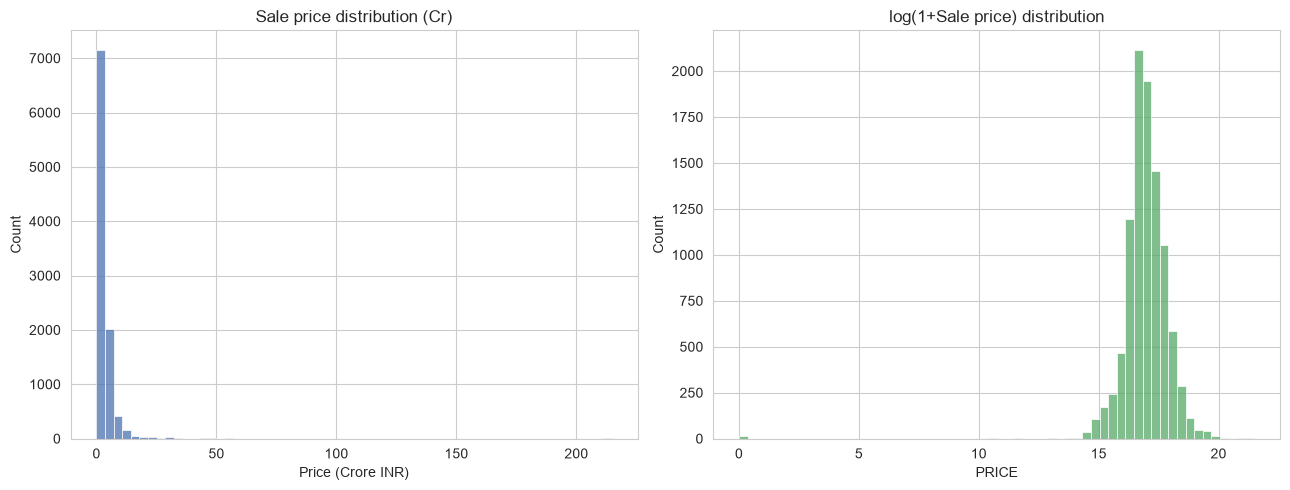

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df_sale['PRICE'] / 1e7, bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_title('Sale price distribution (Cr)')
axes[0].set_xlabel('Price (Crore INR)')

sns.histplot(np.log1p(df_sale['PRICE']), bins=60, ax=axes[1], color='#55A868')
axes[1].set_title('log(1+Sale price) distribution')
plt.tight_layout()
plt.show()


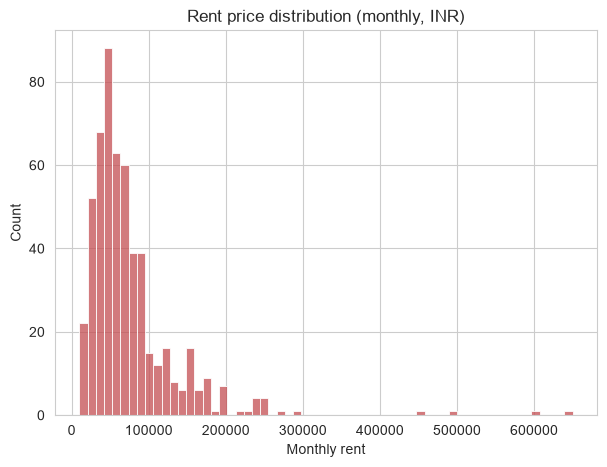

In [22]:
plt.figure(figsize=(7, 5))
sns.histplot(df_rent['PRICE'], bins=60, color='#C44E52')
plt.title('Rent price distribution (monthly, INR)')
plt.xlabel('Monthly rent')
plt.show()


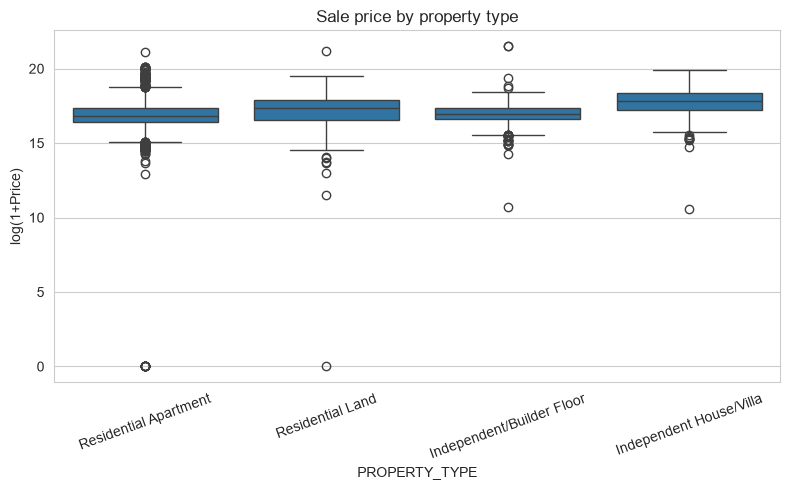

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_sale, x='PROPERTY_TYPE', y=np.log1p(df_sale['PRICE']), ax=ax)
ax.set_ylabel('log(1+Price)')
ax.set_title('Sale price by property type')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


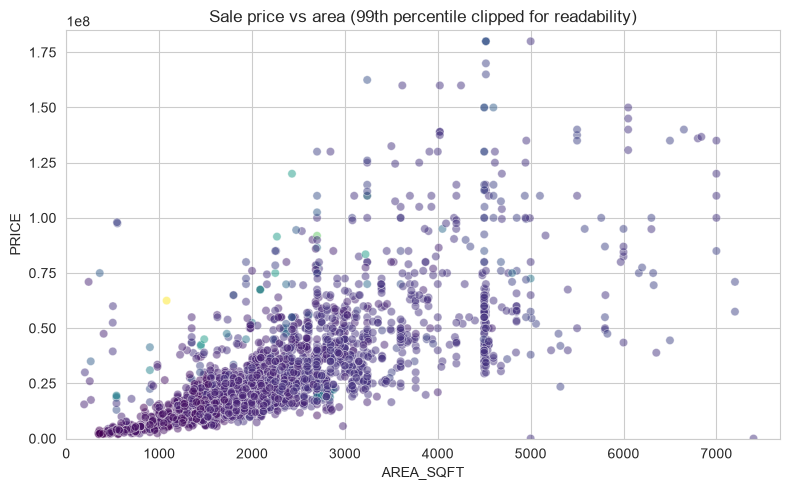

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_sale.sample(min(3000, len(df_sale)), random_state=1),
                 x='AREA_SQFT', y='PRICE', hue='BHK', palette='viridis', alpha=0.5, legend=False)
ax.set_xlim(0, df_sale['AREA_SQFT'].quantile(0.99))
ax.set_ylim(0, df_sale['PRICE'].quantile(0.99))
ax.set_title('Sale price vs area (99th percentile clipped for readability)')
plt.tight_layout()
plt.show()


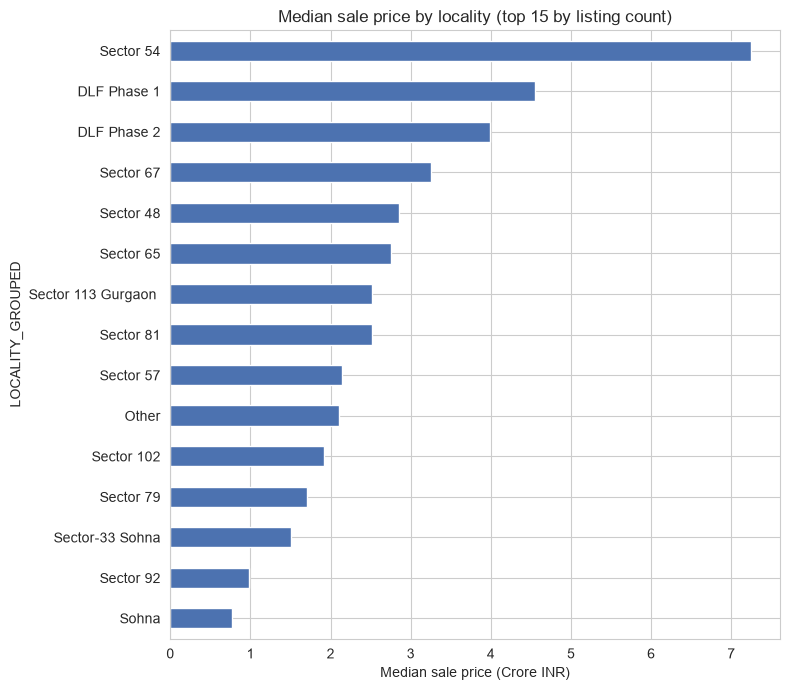

In [25]:
top15 = df_sale['LOCALITY_GROUPED'].value_counts().nlargest(15).index
loc_price = df_sale[df_sale['LOCALITY_GROUPED'].isin(top15)].groupby('LOCALITY_GROUPED')['PRICE'].median().sort_values() / 1e7

plt.figure(figsize=(8, 7))
loc_price.plot(kind='barh', color='#4C72B0')
plt.xlabel('Median sale price (Crore INR)')
plt.title('Median sale price by locality (top 15 by listing count)')
plt.tight_layout()
plt.show()


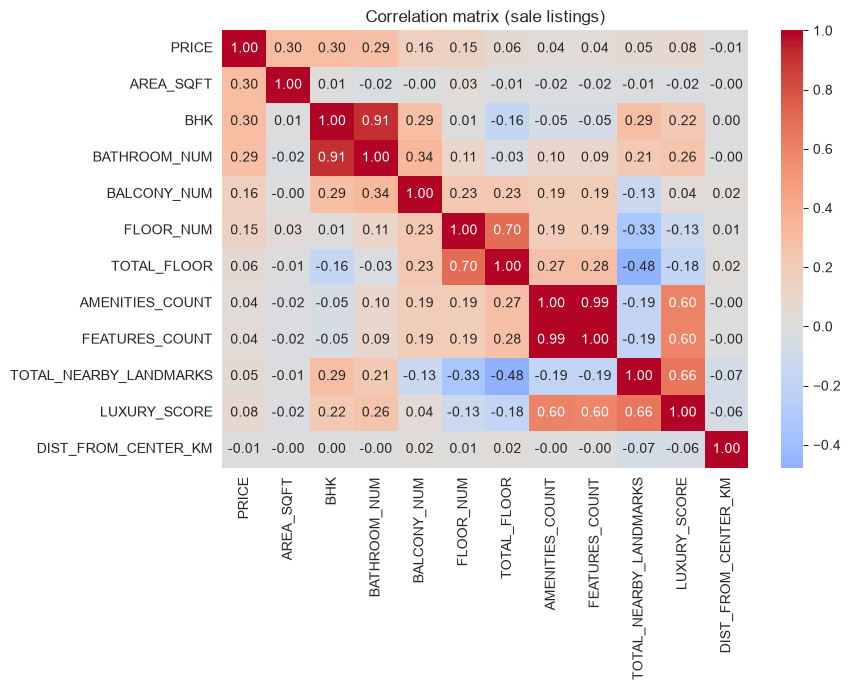

In [26]:
numeric_cols = ['PRICE', 'AREA_SQFT', 'BHK', 'BATHROOM_NUM', 'BALCONY_NUM', 'FLOOR_NUM',
                'TOTAL_FLOOR', 'AMENITIES_COUNT', 'FEATURES_COUNT', 'TOTAL_NEARBY_LANDMARKS',
                'LUXURY_SCORE', 'DIST_FROM_CENTER_KM']
corr = df_sale[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (sale listings)')
plt.tight_layout()
plt.show()


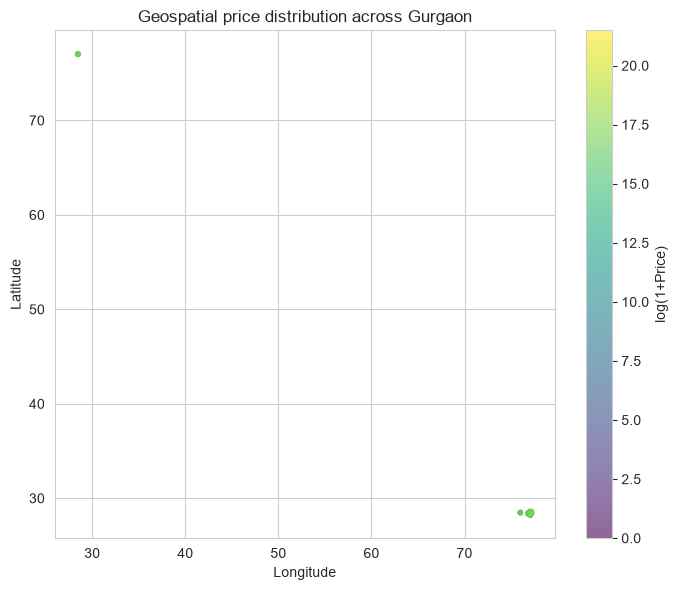

In [27]:
valid_geo = df_sale.dropna(subset=['LATITUDE', 'LONGITUDE'])
plt.figure(figsize=(7, 6))
sc = plt.scatter(valid_geo['LONGITUDE'], valid_geo['LATITUDE'],
                  c=np.log1p(valid_geo['PRICE']), cmap='viridis', s=8, alpha=0.6)
plt.colorbar(sc, label='log(1+Price)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geospatial price distribution across Gurgaon')
plt.tight_layout()
plt.show()


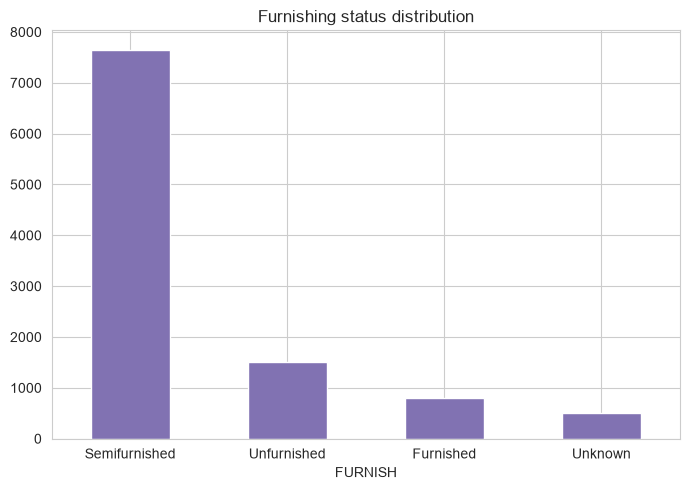

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
df4['FURNISH'].value_counts().plot(kind='bar', ax=ax, color='#8172B2')
ax.set_title('Furnishing status distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Missing Value Imputation

Strategy, column by column:

| Column(s) | Strategy | Rationale |
|---|---|---|
| `AREA_SQFT`, `CARPET_SQFT`, `SUPERBUILTUP_SQFT` | group median by `LOCALITY_GROUPED` + `BHK`, fallback to global median | area correlates strongly with locality & bedroom count |
| `BHK`, `BATHROOM_NUM`, `BALCONY_NUM` | group median by `PROPERTY_TYPE`, fallback global median | correlated with property type |
| `FLOOR_NUM`, `TOTAL_FLOOR`, `BROKERAGE`, `LISTING_DURATION_DAYS` | median | robust to skew, simple |
| `LATITUDE`/`LONGITUDE`/`DIST_FROM_CENTER_KM` | KNN imputer (using other numeric features) | geography isn't well captured by a simple median |
| `SOCIETY_NAME`, `BUILDING_NAME`, `PROP_NAME` | fill with `'Unknown'` | independent houses/plots genuinely have no society |
| `FACING_TEXT` | fill with `'Unknown'` | majority of rows never mention facing in free text |
| `RERA_STATUS` | fill with `'Not Specified'` | absence of RERA tag is itself informative, keep as a category |


In [29]:
df5 = df4.copy()

# --- Group-median impute for area-related numeric columns
for col in ['AREA_SQFT', 'CARPET_SQFT', 'SUPERBUILTUP_SQFT']:
    df5[col] = df5.groupby(['LOCALITY_GROUPED', 'BHK'])[col].transform(lambda s: s.fillna(s.median()))
    df5[col] = df5[col].fillna(df5[col].median())

print(df5[['AREA_SQFT', 'CARPET_SQFT', 'SUPERBUILTUP_SQFT']].isna().sum())


AREA_SQFT            0
CARPET_SQFT          0
SUPERBUILTUP_SQFT    0
dtype: int64


In [30]:
# --- Group-median impute for room-count columns using property type
for col in ['BHK', 'BATHROOM_NUM', 'BALCONY_NUM']:
    df5[col] = df5.groupby('PROPERTY_TYPE')[col].transform(lambda s: s.fillna(s.median()))
    df5[col] = df5[col].fillna(df5[col].median())

# --- Simple median impute
simple_median_cols = ['FLOOR_NUM', 'TOTAL_FLOOR', 'BROKERAGE', 'LISTING_DURATION_DAYS']
imp = SimpleImputer(strategy='median')
df5[simple_median_cols] = imp.fit_transform(df5[simple_median_cols])


In [31]:
# --- KNN impute for geography (uses correlated numeric signals to fill lat/long sensibly)
geo_features = ['LATITUDE', 'LONGITUDE', 'AREA_SQFT', 'PRICE_SQFT', 'BHK']
knn_imp = KNNImputer(n_neighbors=5)
df5[geo_features] = knn_imp.fit_transform(df5[geo_features])

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

GURGAON_CENTER = (28.4595, 77.0266)
df5['DIST_FROM_CENTER_KM'] = haversine_km(df5['LATITUDE'], df5['LONGITUDE'], *GURGAON_CENTER)

# FLOOR_RATIO / IS_TOP_FLOOR were computed in section 5 before FLOOR_NUM/TOTAL_FLOOR were
# imputed -- recompute now so they don't carry stale NaNs.
df5['FLOOR_RATIO'] = df5['FLOOR_NUM'] / df5['TOTAL_FLOOR'].replace(0, np.nan)
df5['FLOOR_RATIO'] = df5['FLOOR_RATIO'].fillna(df5['FLOOR_RATIO'].median())
df5['IS_TOP_FLOOR'] = (df5['FLOOR_NUM'] == df5['TOTAL_FLOOR'])


In [32]:
# --- Categorical fills
df5['SOCIETY_NAME'] = df5['SOCIETY_NAME'].fillna('Unknown')
df5['BUILDING_NAME'] = df5['BUILDING_NAME'].fillna('Unknown')
df5['PROP_NAME'] = df5['PROP_NAME'].fillna('Unknown')
df5['FACING_TEXT'] = df5['FACING_TEXT'].fillna('Unknown')
df5['RERA_STATUS'] = df5['RERA_STATUS'].fillna('Not Specified')
df5['TRANSACT_TYPE_CODE'] = df5['TRANSACT_TYPE_CODE'].cat.add_categories(['Unknown']).fillna('Unknown')

# FURNISH_LABEL is the raw site label the FURNISH column was decoded from (section 3/4) --
# now redundant, drop it. REGISTER_DATE is listing metadata, not a modeling feature; fill
# any stray missing dates with the column median so no NaNs linger.
df5 = df5.drop(columns=['FURNISH_LABEL'])
df5['REGISTER_DATE'] = df5['REGISTER_DATE'].fillna(df5['REGISTER_DATE'].median())

remaining = df5.isna().mean().sort_values(ascending=False)
remaining = remaining[remaining > 0]
print('Columns still with missing values:')
print(remaining if len(remaining) else 'None -- fully imputed.')


Columns still with missing values:
EXPIRY_DATE    0.000191
dtype: float64


## 8. Outlier Detection & Removal

Three complementary passes:
1. **Domain-rule filters** — hard physical/business bounds (e.g. a flat can't be 22 BHK,
   Gurgaon price/sqft outside ₹500–₹1,00,000 is almost certainly a data error).
2. **IQR method** on price and area, applied *within* the Sale/Rent split (their scales differ).
3. **Isolation Forest** as a multivariate check, to catch combinations that look fine
   individually but are jointly unusual (e.g. huge area at a tiny price).


In [33]:
df6 = df5.copy()
before = len(df6)

# --- 1. Domain-rule filters
df6 = df6[df6['BHK'].between(1, 10)]
df6 = df6[df6['BATHROOM_NUM'].between(0, 10)]
df6 = df6[df6['AREA_SQFT'].between(100, 20000)]
df6 = df6[df6['PRICE_SQFT'].between(500, 100000)]
df6 = df6[df6['DIST_FROM_CENTER_KM'] < 60]  # Gurgaon district bound; beyond this = bad geocoding

print(f'Domain-rule filtering: {before} -> {len(df6)} rows ({before - len(df6)} removed)')


Domain-rule filtering: 10446 -> 8884 rows (1562 removed)


In [34]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

before = len(df6)
mask_keep = pd.Series(True, index=df6.index)

for pref, cols in [('Sale', ['PRICE', 'AREA_SQFT']), ('Rent', ['PRICE', 'AREA_SQFT'])]:
    sub = df6[df6['PREFERENCE'] == pref]
    for col in cols:
        lo, hi = iqr_bounds(sub[col])
        out_of_bounds = (df6['PREFERENCE'] == pref) & ((df6[col] < lo) | (df6[col] > hi))
        mask_keep &= ~out_of_bounds

df6 = df6[mask_keep]
print(f'IQR filtering (per Sale/Rent segment): {before} -> {len(df6)} rows ({before - len(df6)} removed)')


IQR filtering (per Sale/Rent segment): 8884 -> 8046 rows (838 removed)


In [35]:
# --- 3. Multivariate check with Isolation Forest (fit per segment, since scales differ)
before = len(df6)
iso_features = ['PRICE', 'AREA_SQFT', 'BHK', 'BATHROOM_NUM', 'PRICE_SQFT']

keep_idx = []
for pref in ['Sale', 'Rent']:
    sub = df6[df6['PREFERENCE'] == pref]
    iso = IsolationForest(contamination=0.02, random_state=42)
    pred = iso.fit_predict(sub[iso_features])
    keep_idx.extend(sub.index[pred == 1])

df6 = df6.loc[keep_idx].sort_index()
print(f'Isolation Forest filtering: {before} -> {len(df6)} rows ({before - len(df6)} removed)')


Isolation Forest filtering: 8046 -> 7884 rows (162 removed)


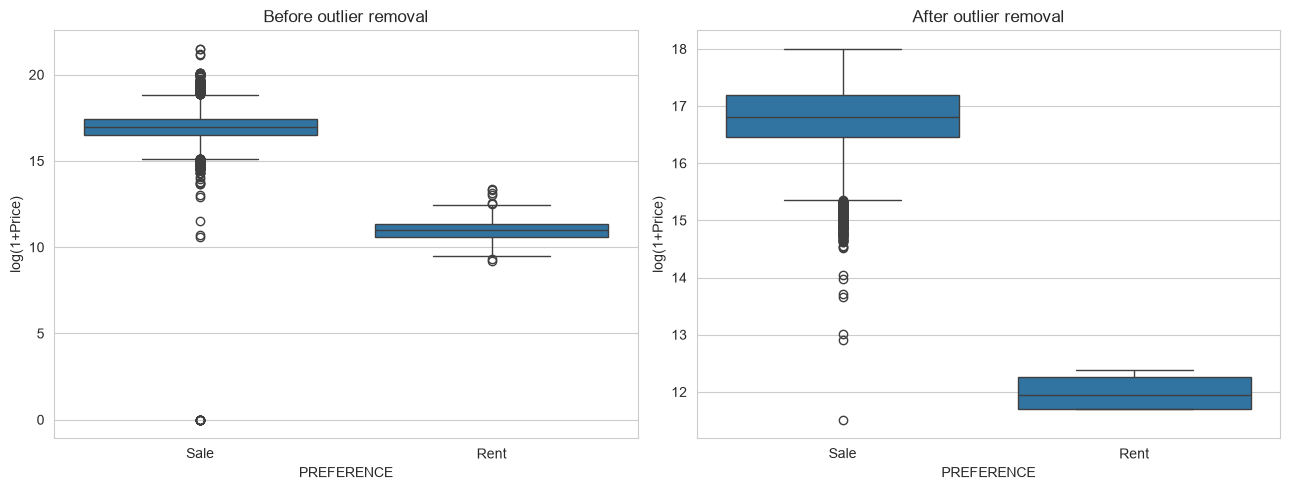

Total rows: raw=10704  cleaned+featured=10446  final (no outliers)=7884


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df5, x='PREFERENCE', y=np.log1p(df5['PRICE']), ax=axes[0])
axes[0].set_title('Before outlier removal')
axes[0].set_ylabel('log(1+Price)')

sns.boxplot(data=df6, x='PREFERENCE', y=np.log1p(df6['PRICE']), ax=axes[1])
axes[1].set_title('After outlier removal')
axes[1].set_ylabel('log(1+Price)')
plt.tight_layout()
plt.show()

print(f'Total rows: raw={len(df)}  cleaned+featured={len(df5)}  final (no outliers)={len(df6)}')


## 9. Export Final Dataset

Two artifacts are saved:
- `gurgaon_flats_cleaned.csv` — full cleaned + feature-engineered + imputed dataset,
  outliers **retained** (in case you want to inspect them or use robust models).
- `gurgaon_flats_final.csv` — outliers removed, ready to feed into a model.


In [37]:
df5.to_csv(f'{OUT_DIR}/gurgaon_flats_cleaned.csv', index=False)
df6.to_csv(f'{OUT_DIR}/gurgaon_flats_final.csv', index=False)

print('Saved gurgaon_flats_cleaned.csv:', df5.shape)
print('Saved gurgaon_flats_final.csv  :', df6.shape)
df6.head(3)


Saved gurgaon_flats_cleaned.csv: (10446, 56)
Saved gurgaon_flats_final.csv  : (7884, 56)


,PROP_ID,PREFERENCE,DESCRIPTION,PROPERTY_TYPE,TRANSACT_TYPE_CODE,OWNTYPE_CODE,BHK,BATHROOM_NUM,BALCONY_NUM,FURNISH,FACING_CODE,AGE_CODE,FLOOR_NUM,TOTAL_FLOOR,REGISTER_DATE,PROP_NAME,PRICE,PRICE_SQFT,CARPET_SQFT,SUPERBUILTUP_SQFT,BROKERAGE,AREA_SQFT,EXPIRY_DATE,CLASS_LABEL,SOCIETY_NAME,BUILDING_NAME,LOCALITY,LATITUDE,LONGITUDE,RERA_STATUS,IS_READY_TO_MOVE,IS_RESALE,IS_RERA,IS_GATED_COMMUNITY,IS_HUDA_APPROVED,FACING_TEXT,USP_COUNT,NEARBY_SHOPPING,NEARBY_EDUCATION,NEARBY_HOSPITAL,NEARBY_METROSTATION,NEARBY_RAILWAYSTATION,NEARBY_CONNECTIVITY,NEARBY_BANK,NEARBY_PARK,TOTAL_NEARBY_LANDMARKS,AMENITIES_COUNT,FEATURES_COUNT,LISTING_DURATION_DAYS,FLOOR_RATIO,IS_GROUND_FLOOR,IS_TOP_FLOOR,PRICE_PER_SQFT_CALC,DIST_FROM_CENTER_KM,LOCALITY_GROUPED,LUXURY_SCORE
0,O71585872,Sale,4 bhk flat for resale in alpha corp gurgaon one,Residential Apartment,1.0,1,4.0,4,4.0,Semifurnished,1,2,14.0,26.0,2023-09-29,Alpha Corp GurgaonOne 84,26300000,8766.0,3000.0,3434.0,263000.0,3433.995198,2023-11-28,Dealer,Alpha Corp GurgaonOne 84,Alpha Corp GurgaonOne 84,Sector 84,28.406534,76.962792,RERA,True,True,False,False,False,North,4,4,2,1,0,0,0,1,1,10.0,19,18,60.0,0.538462,False,False,7658.717756,8.579943,Other,22.9
1,T71585466,Sale,"Explore dlf ultima, an upscale ready-To-Move h...",Residential Apartment,1.0,1,4.0,4,3.0,Semifurnished,1,1,7.0,29.0,2023-09-29,DLF The Ultima,36000000,21176.0,1700.0,2870.0,1.0,2869.995987,2023-11-28,Dealer,DLF The Ultima,DLF The Ultima,Sector 81,28.388907,76.951328,RERA,True,True,True,False,False,North,4,1,2,1,1,1,2,0,0,9.0,25,22,60.0,0.241379,False,False,12543.571547,10.760970,Sector 81,26.6
3,I71493958,Sale,Looking for a 3 bhk property for purchase in g...,Residential Apartment,1.0,1,3.0,3,3.0,Semifurnished,0,1,14.0,28.0,2023-09-23,Experion Windchants,38500000,13740.0,1600.0,2802.0,1.0,2801.996082,2023-11-22,Dealer,Experion Windchants,Experion Windchants,Sector 112,28.518677,77.015115,RERA,True,True,True,False,False,Unknown,4,1,2,2,0,1,1,0,0,8.0,19,17,60.0,0.500000,False,False,13740.204795,6.675226,Other,21.6


## Summary

- **Raw data:** 10,704 rows × 67 columns of raw scraped output.
- **Pipeline applied:** column pruning → JSON/nested-field parsing → dtype cleaning &
  de-duplication → feature engineering (floor position, geography, amenity/luxury scores,
  cardinality-reduced locality) → EDA → missing value imputation → 3-stage outlier removal.
- **Output:** `gurgaon_flats_cleaned.csv` (imputed, outliers kept) and
  `gurgaon_flats_final.csv` (outliers removed, modeling-ready).

**Natural next steps:** one-hot/target-encode the remaining categoricals
(`PROPERTY_TYPE`, `LOCALITY_GROUPED`, `FURNISH`, `FACING_CODE`, `AGE_CODE`), log-transform
`PRICE` for the Sale segment (it's heavily right-skewed), and do a train/test split
stratified by `PREFERENCE` and `PROPERTY_TYPE` before modeling.
